<a href="https://colab.research.google.com/github/mochamadx5/PCVK26_11_MochamadReza/blob/main/P5_Praktikum_11_Mochamad_Reza_Firdaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA  :  Mochamad Reza Firdaus
NIM   :  244107020104  | N =  104
bins  : 8
clip  : 3.0
tile  : 2
L     : 8
WAKTU :  2026-10-03 13:39:09 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 6325471379f92b99


Text(0.5, 1.0, '244107020104 - CLAHE clip 3.0')

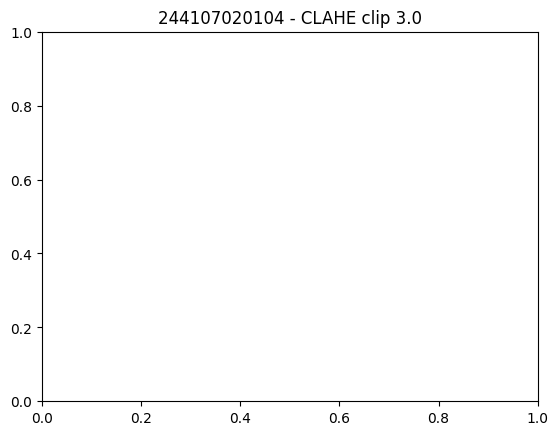

In [80]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import hashlib
import datetime
import zoneinfo
import platform
import sys
import matplotlib.pyplot as plt

NAMA = 'Mochamad Reza Firdaus'
NIM = '244107020104'

N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  : ', NAMA)
print('NIM   : ', NIM, ' | N = ', N)
for k, v in PARAM.items():
  print('%-6s: %s' % (k, v))
print('WAKTU : ', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

In [81]:
from google.colab import drive
drive.mount('/content/drive')
# Path folder Google Drive
BASE_PATH = '/content/drive/MyDrive/PCVK/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


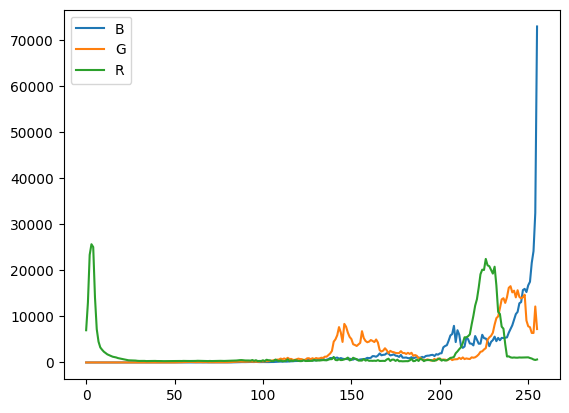

In [82]:
import numpy as np, cv2 as cv, matplotlib.pyplot as plt

def histogram_manual(img, L=256):
  h = np.zeros(L, dtype=np.float32)
  for y in range(img.shape[0]):
    for x in range(img.shape[1]):
      h[img[y, x]] += 1
  return h

# Membaca citra grayscale (pastikan Google Drive sudah di-mount & path benar)
gray = cv.imread(BASE_PATH + 'KTM1b.jpg', cv.IMREAD_GRAYSCALE)
if gray is None:
    print(f"Gagal membaca file dari {BASE_PATH + '/KTM1b.jpg'}. Silakan periksa mount Drive Anda.")
else:
    h = histogram_manual(gray)
    p = h / gray.size
    cdf = np.cumsum(p)
    assert h.sum() == gray.size

# Citra berwarna
bgr = cv.imread(BASE_PATH + 'KTM1d.jpg')
if bgr is None:
    print(f"Gagal membaca file dari {BASE_PATH + 'KTM1d.jpg'}. Silakan periksa mount Drive Anda.")
else:
    for i, nama in enumerate(['B', 'G', 'R']):
      plt.plot(histogram_manual(bgr[:, :, i]), label=nama)
    plt.legend()
    plt.show()

In [83]:
def floyd_steinberg(gray, L=2):
  img  = gray.astype(np.float32).copy()
  step = 255.0 / (L - 1)
  H, W = img.shape
  for y in range(H):
    for x in range(W):
      lama  = img[y, x]
      baru  = np.round(lama / step) * step      # warna palet terdekat
      img[y, x] = baru
      error = lama - baru
      if x + 1 < W:              img[y,   x+1] += error * 7 / 16
      if x > 0     and y+1 < H:  img[y+1, x-1] += error * 3 / 16
      if y + 1 < H:              img[y+1, x  ] += error * 5 / 16
      if x + 1 < W and y+1 < H:  img[y+1, x+1] += error * 1 / 16
  return np.clip(img, 0, 255).astype(np.uint8)

In [84]:
# E1 PERCOBAAN HISTOGRAM
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

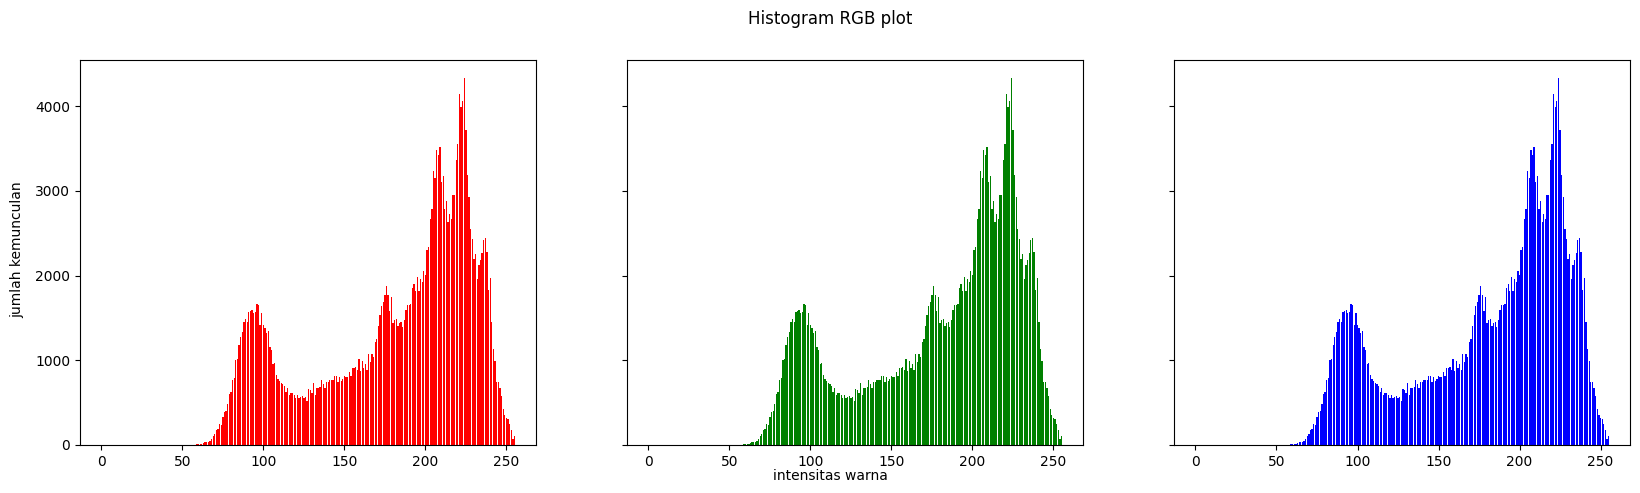

In [85]:
img = cv.imread(BASE_PATH + 'lena.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][0]] += 1
    blue[img[y][x][0]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex = True, sharey = True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'intensitas warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [86]:
# 1. Perbandingan Histogram: Manual, NumPy, dan OpenCV (cv.calcHist)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.float32)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

# Daftar citra yang akan diuji
image_files = ['lena.jpg', 'KTM1b.jpg']

for filename in image_files:
    # Membaca citra dalam mode grayscale
    img = cv.imread(BASE_PATH + 'lena.png', cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"File {filename} tidak ditemukan di {BASE_PATH}. Lewati pengujian.")
        continue

    # 1. Metode Manual
    h_manual = histogram_manual(img)

    # 2. Metode NumPy (numpy.histogram)
    h_np, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    h_np = h_np.astype(np.float32)

    # 3. Metode OpenCV (cv.calcHist)
    h_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()

    # Menghitung selisih maksimum
    diff_manual_np = np.max(np.abs(h_manual - h_np))
    diff_manual_cv = np.max(np.abs(h_manual - h_cv))

    print(f"--- Hasil Pengujian untuk {filename} ---")
    print(f"Selisih maksimum (Manual vs NumPy) : {diff_manual_np}")
    print(f"Selisih maksimum (Manual vs OpenCV): {diff_manual_cv}\n")


--- Hasil Pengujian untuk lena.jpg ---
Selisih maksimum (Manual vs NumPy) : 0.0
Selisih maksimum (Manual vs OpenCV): 0.0

--- Hasil Pengujian untuk KTM1b.jpg ---
Selisih maksimum (Manual vs NumPy) : 0.0
Selisih maksimum (Manual vs OpenCV): 0.0



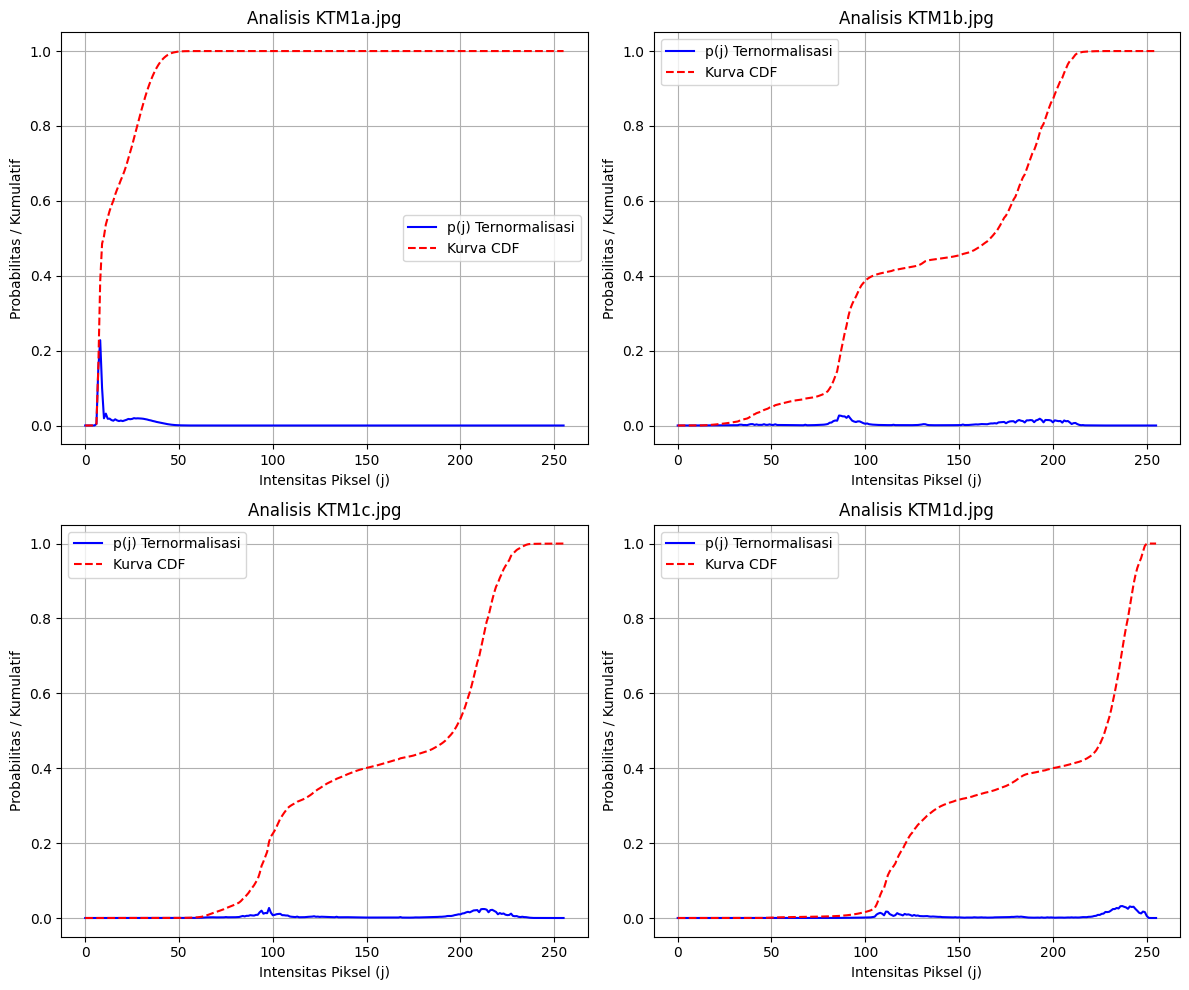

In [87]:
#2. Histogram Ternormalisasi $p(j)$ dan Kurva CDF (KTM1a.jpg s.d. KTM1d.jpg)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

for idx, fname in enumerate(files):
    row, col = divmod(idx, 2)
    img = cv.imread(BASE_PATH + fname, cv.IMREAD_GRAYSCALE)

    if img is not None:
        h = histogram_manual(img)
        p = h / img.size             # Normalisasi histogram p(j)
        cdf = np.cumsum(p)           # Kurva CDF

        ax = axes[row, col]
        ax.plot(p, label='p(j) Ternormalisasi', color='blue')
        ax.plot(cdf, label='Kurva CDF', color='red', linestyle='--')
        ax.set_title(f'Analisis {fname}')
        ax.set_xlabel('Intensitas Piksel (j)')
        ax.set_ylabel('Probabilitas / Kumulatif')
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()

Analisis Bentuk Kurva CDF dan Kondisi Pencahayaan :
Citra Paling Gelap (Underexposed): Kurva CDF akan melonjak naik dengan cepat di bagian awal (sisi kiri sumbu x, nilai intensitas rendah). Hal ini menunjukkan bahwa sebagian besar piksel terkonsentrasi pada tingkat keabuan yang gelap. Kaitannya dengan kondisi pencahayaan saat akuisisi: pencahayaan ruangan/sumber cahaya sangat kurang, atau objek membelakangi sumber cahaya (backlight), sehingga detail pada area gelap menumpuk.

Citra Paling Terang (Overexposed): Kurva CDF cenderung datar di awal dan baru melesat naik di bagian akhir (sisi kanan sumbu x, nilai intensitas tinggi). Ini menunjukkan dominasi piksel cerah atau putih. Kaitannya dengan kondisi pencahayaan saat akuisisi: intensitas cahaya lampu atau matahari terlalu kuat atau menggunakan pencahayaan langsung yang terlalu dekat, menyebabkan beberapa detail citra mengalami saturation (pembakaran piksel/terlalu silau).

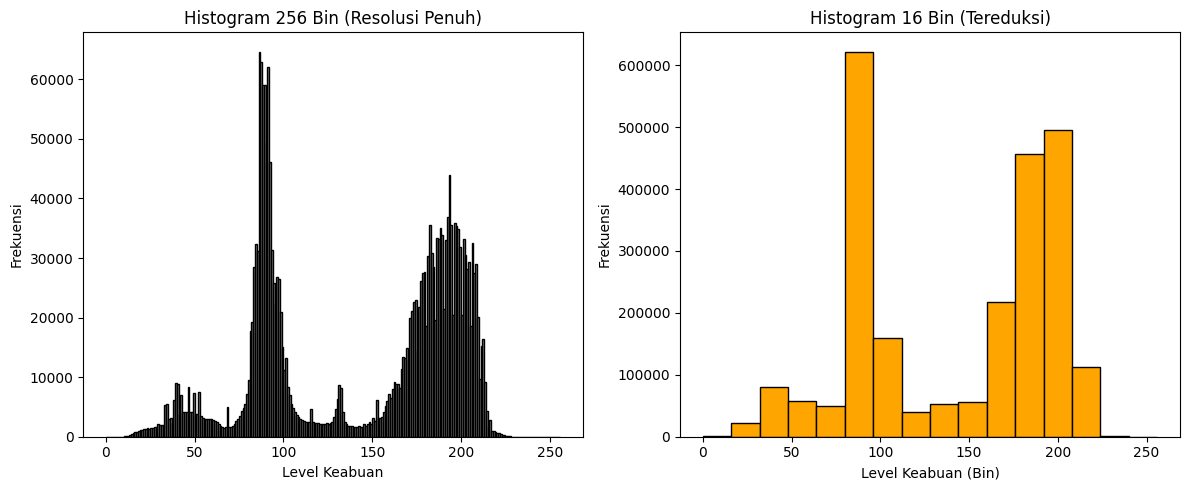

In [88]:
# 3. Perbandingan Jumlah Bin (PARAM['bins'] vs 256 Bin) pada KTM1b.jpg
PARAM = {'bins': 16}  # Contoh jumlah bin yang dikurangi

img = cv.imread(BASE_PATH + 'KTM1b.jpg', cv.IMREAD_GRAYSCALE)
if img is not None:
    plt.figure(figsize=(12, 5))

    # Histogram 256 Bin
    plt.subplot(1, 2, 1)
    plt.hist(img.flatten(), bins=256, range=[0, 256], color='gray', edgecolor='black')
    plt.title('Histogram 256 Bin (Resolusi Penuh)')
    plt.xlabel('Level Keabuan')
    plt.ylabel('Frekuensi')

    # Histogram dengan PARAM['bins']
    plt.subplot(1, 2, 2)
    plt.hist(img.flatten(), bins=PARAM['bins'], range=[0, 256], color='orange', edgecolor='black')
    plt.title(f"Histogram {PARAM['bins']} Bin (Tereduksi)")
    plt.xlabel('Level Keabuan (Bin)')
    plt.ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

Informasi yang Hilang Saat Jumlah Bin
Dikurangi:
- Detail Gradasi Halus : Ketika bin dikurangi dari 256 ke nilai yang lebih kecil (misal 16), rentang intensitas digabungkan ke dalam kelompok interval tertentu. Akibatnya, perbedaan halus antar tingkat keabuan yang berdekatan menjadi hilang.

- Kontras Lokal & Nuansa Tekstur: Detail tekstur halus pada objek atau latar belakang citra akan melebur, yang dapat menyebabkan efek false contouring (pembentukan garis kontur palsu) pada citra hasil pengolahan.

- Resolusi Intensitas: Menurunkan jumlah bin berarti menurunkan resolusi spasial intensitas yaitu meningkatkan kuantisasi kasar, sehingga informasi statistik piksel yang spesifik tidak dapat direpresentasikan secara akurat.

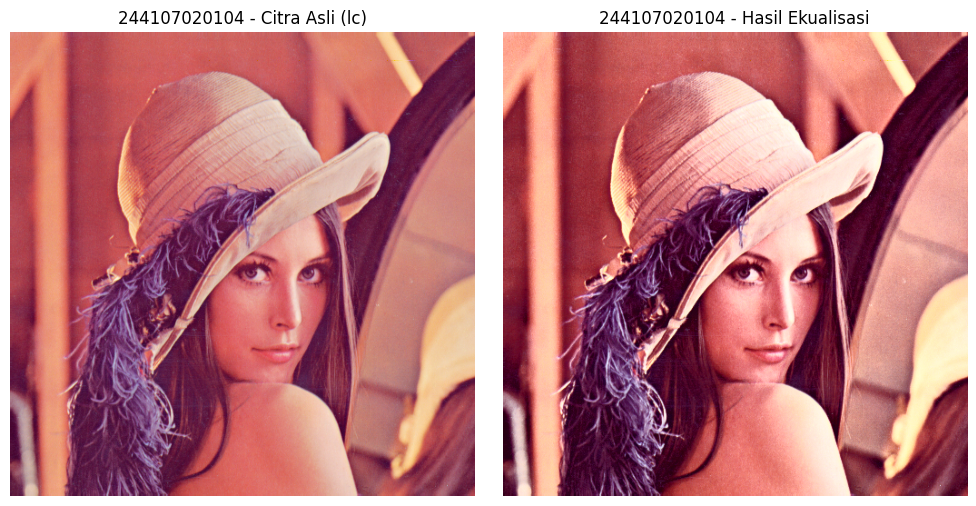

In [89]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Gunakan citra contoh lena_lc.jpg untuk Tahap 1
berkas = BASE_PATH + 'lena.png'  # Menggunakan BASE_PATH yang benar
bgr = cv.imread(berkas)

if bgr is None:
    print(f"File tidak ditemukan di {berkas}. Periksa path Anda.")
else:
    # Ekualisasi pada ruang warna YCrCb (Kanal Y saja yang diekuilisasi agar warna tetap alami)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    y_eq = cv.equalizeHist(y)
    he_y = cv.cvtColor(cv.merge([y_eq, cr, cb]), cv.COLOR_YCrCb2BGR)

    # Konversi BGR ke RGB untuk ditampilkan dengan matplotlib
    img_asli_rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
    img_hasil_rgb = cv.cvtColor(he_y, cv.COLOR_BGR2RGB)

    # Menampilkan berdampingan sesuai format contoh di modul
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_asli_rgb)
    plt.title(f"{NIM} - Citra Asli (lc)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_hasil_rgb)
    plt.title(f"{NIM} - Hasil Ekualisasi")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Selisih maksimum (Manual vs equalizeHist pada kanal B): 0
Penyebab selisih (jika tidak nol): Perbedaan optimasi tipe data dan fungsi pembulatan float C++ OpenCV.



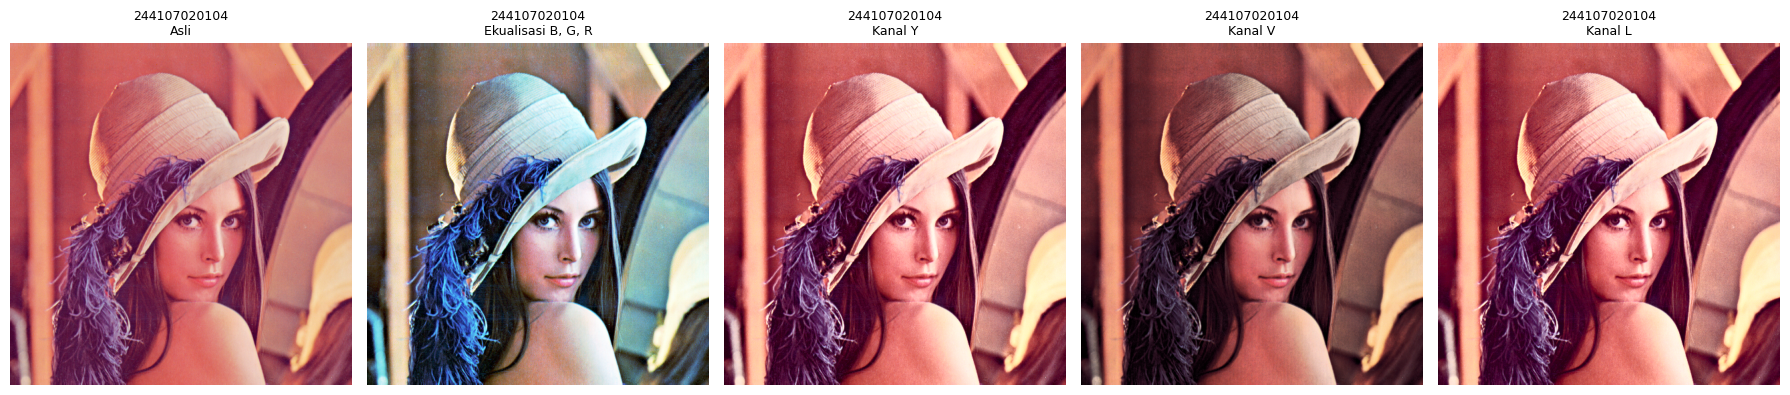

In [90]:
# ==========================================
# E-2 NOMOR 2, 3, DAN 4: EKUALISASI CITRA BERWARNA & ANALISIS HUE
# ==========================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Fungsi perhitungan pergeseran Hue sesuai modul
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d) # Hue melingkar 0-179
    return d.mean()

# Tahap 1: Gunakan citra contoh (lena.png)
berkas = BASE_PATH + 'lena.png'  # Menggunakan BASE_PATH yang benar
bgr = cv.imread(berkas)

if bgr is None:
    print(f"Gagal membaca file dari {berkas}. Periksa path direktori Anda.")
else:
    # --- E-2 No. 2: Perbandingan manual vs equalizeHist pada kanal terpisah ---
    # Contoh pada kanal B (Biru)
    b_chan, g_chan, r_chan = cv.split(bgr)
    eq_cv_b = cv.equalizeHist(b_chan)

    # Ekualisasi manual kanal B menggunakan CDF
    h_b, _ = np.histogram(b_chan.flatten(), bins=256, range=[0, 256])
    cdf_b = np.cumsum(h_b / b_chan.size)
    eq_man_b = np.round(cdf_b * 255).astype(np.uint8)[b_chan]
    diff_no2 = np.max(np.abs(eq_man_b.astype(np.int32) - eq_cv_b.astype(np.int32)))
    print(f"Selisih maksimum (Manual vs equalizeHist pada kanal B): {diff_no2}")
    print("Penyebab selisih (jika tidak nol): Perbedaan optimasi tipe data dan fungsi pembulatan float C++ OpenCV.\n")

    # --- E-2 No. 3: Cara 1 - Tiap kanal B, G, R diekuilisasi sendiri-sendiri ---
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # --- E-2 No. 4: Cara 2 - Hanya kanal terang yang diekuilisasi (YCrCb, HSV, LAB) ---
    # 1. Ruang Warna YCrCb (Kanal Y)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # 2. Ruang Warna HSV (Kanal V)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # 3. Ruang Warna LAB (Kanal L)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l_chan, a_chan, b_chan_lab = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l_chan), a_chan, b_chan_lab]), cv.COLOR_LAB2BGR)

    # Varian tambahan nomor 4 (CLAHE pada kanal terang Y)
    N_val = int(NIM[-3:])
    clip_val = round(1.0 + (N_val % 5) * 0.5, 1)
    tile_val = (N_val % 4) + 2

    clahe_obj = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(tile_val, tile_val))
    he_y_clahe = cv.cvtColor(cv.merge([clahe_obj.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # --- Tampilkan 5 Gambar Berdampingan Sesuai Modul ---
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(f"{NIM}\n{t}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    def geser_hue(asli, hasil):
      h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
      h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
      d  = np.abs(h1 - h2)
      d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
      return d.mean()

      print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
      for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                       cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Selisih maksimum (Manual vs equalizeHist kanal B): 0


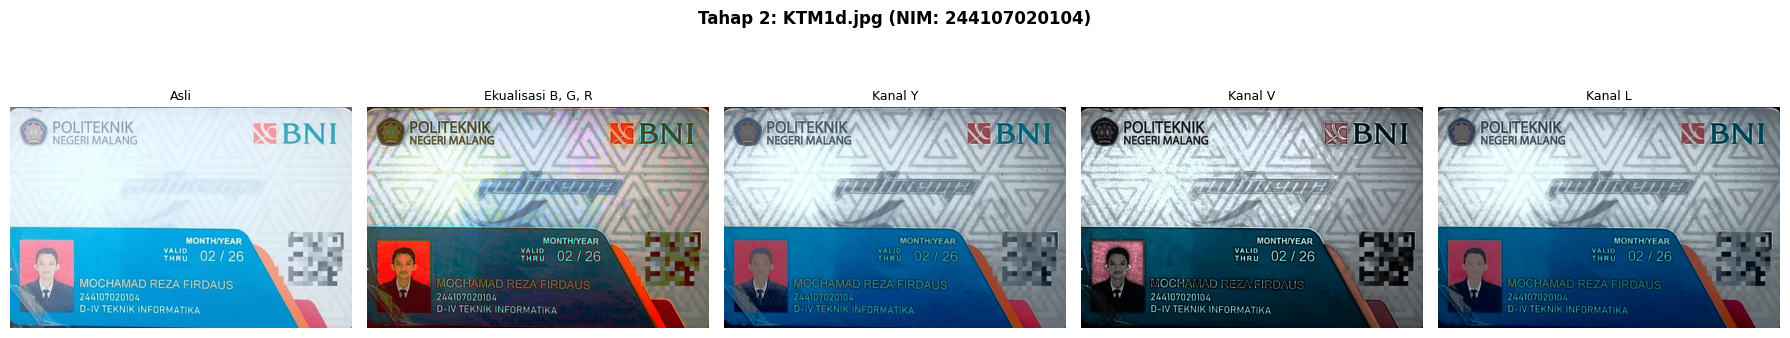

In [91]:
# ==========================================
# E-2 TAHAP 2: MENGGUNAKAN CITRA KTM PRIBADI (KTM1d.jpg)
# ==========================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca citra KTM pribadi menggunakan BASE_PATH yang benar
berkas_ktm = BASE_PATH + 'KTM1d.jpg'
bgr_ktm = cv.imread(berkas_ktm)

if bgr_ktm is None:
    print(f"Gagal membaca file dari {berkas_ktm}. Periksa path atau mount Drive Anda.")
else:
    # 1. Perbandingan Manual vs equalizeHist pada Kanal B
    b_chan, g_chan, r_chan = cv.split(bgr_ktm)
    eq_cv_b = cv.equalizeHist(b_chan)

    h_b, _ = np.histogram(b_chan.flatten(), bins=256, range=[0, 256])
    cdf_b = np.cumsum(h_b / b_chan.size)
    eq_man_b = np.round(cdf_b * 255).astype(np.uint8)[b_chan]
    diff_no2 = np.max(np.abs(eq_man_b.astype(np.int32) - eq_cv_b.astype(np.int32)))
    print(f"Selisih maksimum (Manual vs equalizeHist kanal B): {diff_no2}")

    # 2. Ekualisasi Kanal B, G, R terpisah (Cara 1)
    kanal = list(cv.split(bgr_ktm))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # 3. Ekualisasi Kanal Terang (Cara 2: YCrCb, HSV, LAB)
    ycrcb = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    #  varian setara pada ruang warna lain
    hsv = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2LAB)
    l_chan, a_chan, b_chan_lab = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l_chan), a_chan, b_chan_lab]), cv.COLOR_LAB2BGR)

    # Visualisasi
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr_ktm, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    plt.suptitle(f"Tahap 2: KTM1d.jpg (NIM: {NIM})", fontsize=12, fontweight='bold')
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(t, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    def geser_hue(asli, hasil):
      h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
      h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
      d  = np.abs(h1 - h2)
      d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
      return d.mean()

      print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
      for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                       cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Pertanyaan Analisis E-2 :
1. Cara mana yang menghasilkan pergeseran Hue paling besar?
 - Cara Ekualisasi kanal B, G, dan R secara terpisah menghasilkan pergeseran Hue yang paling besar. Hal ini karena masing-masing kanal warna diubah secara independen, sehingga keseimbangan warna rusak dan warna asli objek bergeser drastis.
2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?
- Disebabkan oleh proses pembulatan (rounding) dan pemotongan (truncating / clipping) ketika matriks citra dikonversi bolak-balik antara ruang warna, misal BGR ke YCrCb lalu dikembalikan ke BGR. Keterbatasan presisi angka desimal dalam representasi citra digital 8-bit menimbulkan sedikit distorsi warna sekunder.
3. Mana kanal yang paling sesuai untuk foto KTM Anda?
Kanal Y (pada ruang warna YCrCb) atau
- Kanal L pada LAB paling sesuai. Alasannya, pemisahan kanal kecerahan dari informasi warna murni menjaga agar warna latar belakang KTM/warna cetak kartu tidak rusak, sementara kontras teks hitam/putih meningkat tajam sehingga identitas lebih mudah dibaca.
4. Perbandingan dengan CLAHE pada kanal terang:
Ketika menggunakan CLAHE pada kanal $Y$ (clipLimit = PARAM['clip']), pergeseran Hue tetap dijaga sekecil mungkin, namun distribusi kontras lokal menjadi jauh lebih merata dibandingkan ekualisasi global biasa, sehingga area teks yang terkena bayangan atau kurang cahaya pada KTM menjadi sangat tajam terbaca.

Nilai PSNR (Asli vs Global Equalization): 5.58 dB


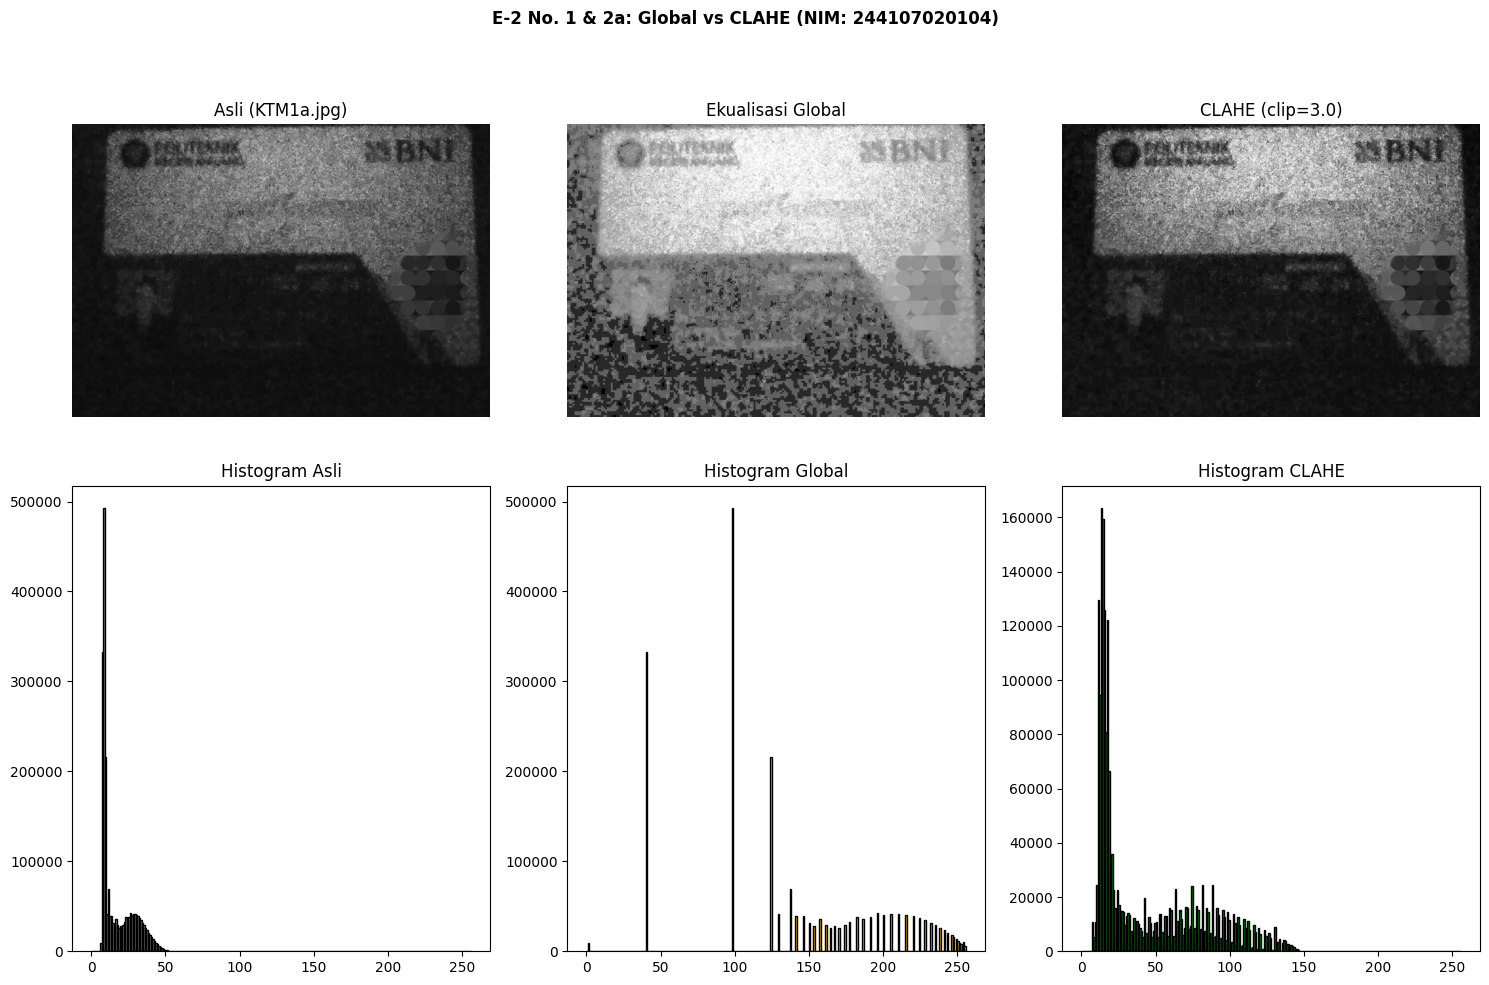

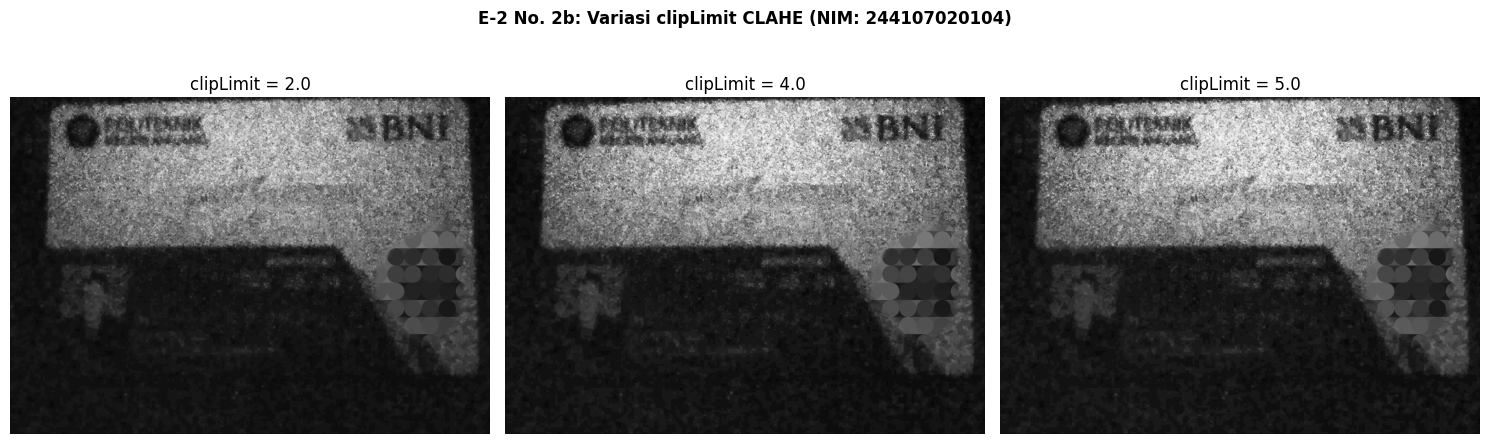

In [92]:
# ==========================================
# E-2 PERTANYAAN PRAKTIKUM: EKUALISASI GLOBAL & CLAHE (KTM1a.jpg)
# ==========================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Fungsi menghitung PSNR
def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse))

# Membaca citra KTM1a.jpg dalam mode grayscale menggunakan BASE_PATH yang benar
berkas_ktm = BASE_PATH + 'KTM1a.jpg'
img_gray = cv.imread(berkas_ktm, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    print(f"Gagal membaca file dari {berkas_ktm}. Periksa path atau mount Drive Anda.")
else:
    # --- 1. Ekualisasi Global (Manual & OpenCV) ---
    h, _ = np.histogram(img_gray.flatten(), bins=256, range=[0, 256])
    p = h / img_gray.size
    cdf = np.cumsum(p)
    img_eq_manual = np.round(cdf * 255).astype(np.uint8)[img_gray]

    img_global_cv = cv.equalizeHist(img_gray)

    # Hitung PSNR antara citra asli dan ekualisasi global
    psnr_val = calculate_psnr(img_gray, img_global_cv)
    print(f"Nilai PSNR (Asli vs Global Equalization): {psnr_val:.2f} dB")

    # --- 2a. CLAHE dengan parameter dari NIM (Dihitung lokal agar aman dari overwriting PARAM) ---
    N_local = int(NIM[-3:])
    clip_default = round(1.0 + (N_local % 5) * 0.5, 1)
    tile_default = (N_local % 4) + 2

    clahe_default = cv.createCLAHE(clipLimit=clip_default, tileGridSize=(tile_default, tile_default))
    img_clahe_default = clahe_default.apply(img_gray)

    # --- Visualisasi Nomor 1 & 2a (Asli, Global, CLAHE + Histogram) ---
    plt.figure(figsize=(15, 10))
    plt.suptitle(f"E-2 No. 1 & 2a: Global vs CLAHE (NIM: {NIM})", fontsize=12, fontweight='bold')

    # Baris 1: Citra
    plt.subplot(2, 3, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Asli (KTM1a.jpg)")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(img_global_cv, cmap='gray')
    plt.title("Ekualisasi Global")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(img_clahe_default, cmap='gray')
    plt.title(f"CLAHE (clip={clip_default})")
    plt.axis('off')

    # Baris 2: Histogram
    plt.subplot(2, 3, 4)
    plt.hist(img_gray.flatten(), bins=256, range=[0, 256], color='gray', edgecolor='black')
    plt.title("Histogram Asli")

    plt.subplot(2, 3, 5)
    plt.hist(img_global_cv.flatten(), bins=256, range=[0, 256], color='orange', edgecolor='black')
    plt.title("Histogram Global")

    plt.subplot(2, 3, 6)
    plt.hist(img_clahe_default.flatten(), bins=256, range=[0, 256], color='green', edgecolor='black')
    plt.title(f"Histogram CLAHE")

    plt.tight_layout()
    plt.show()

    # --- 2b. Percobaan Tiga Nilai clipLimit Lain di Sekitar Nilai PARAM['clip'] ---
    # Menentukan 3 variasi clipLimit di sekitar clip_default
    clip_variasi = [max(1.0, clip_default - 1.0), clip_default + 1.0, clip_default + 2.0]

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"E-2 No. 2b: Variasi clipLimit CLAHE (NIM: {NIM})", fontsize=12, fontweight='bold')

    for idx, c_val in enumerate(clip_variasi, 1):
        clahe_var = cv.createCLAHE(clipLimit=c_val, tileGridSize=(tile_default, tile_default))
        img_var = clahe_var.apply(img_gray)

        plt.subplot(1, 3, idx)
        plt.imshow(img_var, cmap='gray')
        plt.title(f"clipLimit = {c_val:.1f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Menjalankan Dithering untuk Tahap 1: lena.png (L = 8)...


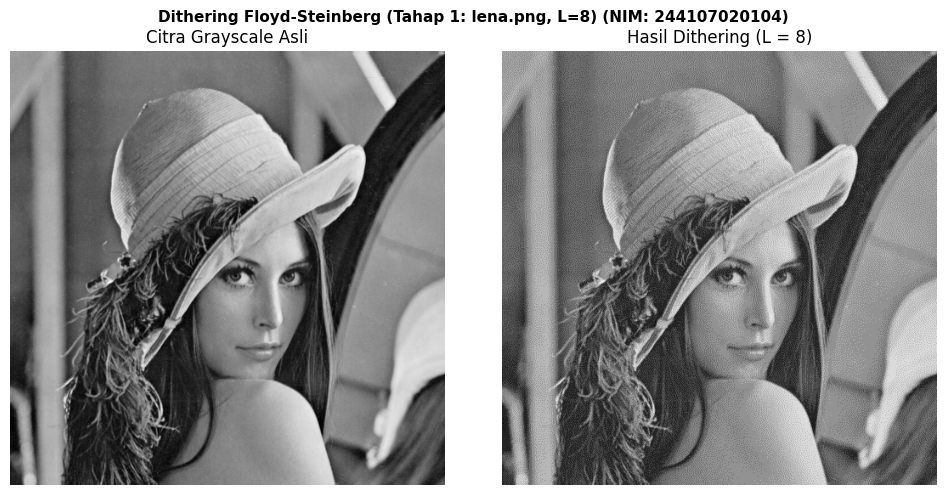

Menjalankan Dithering untuk Tahap 2: KTM1b.jpg (L = 8)...


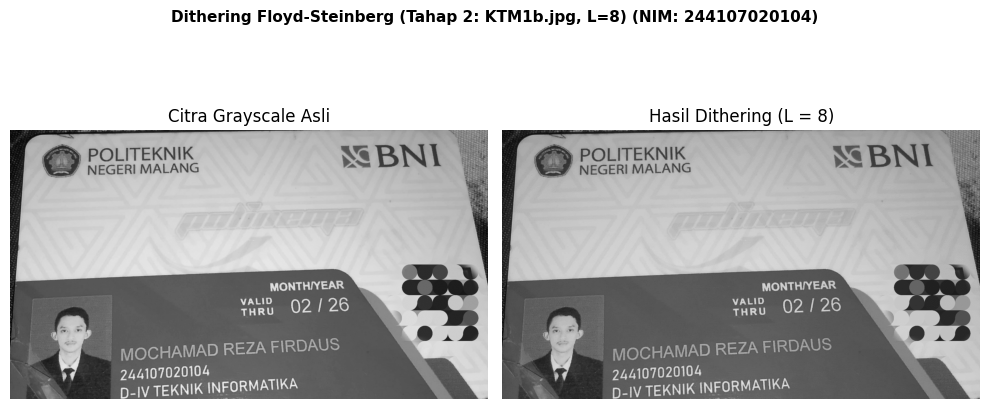

Menjalankan Analisis Ekualisasi & Dithering untuk Tahap 1: lena.png...


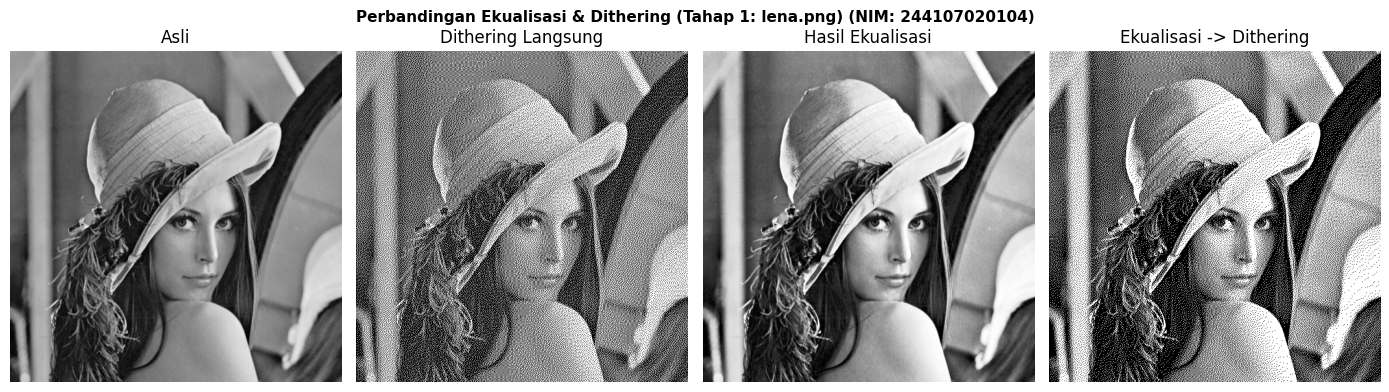

Menjalankan Analisis Ekualisasi & Dithering untuk Tahap 2: KTM1a.jpg...


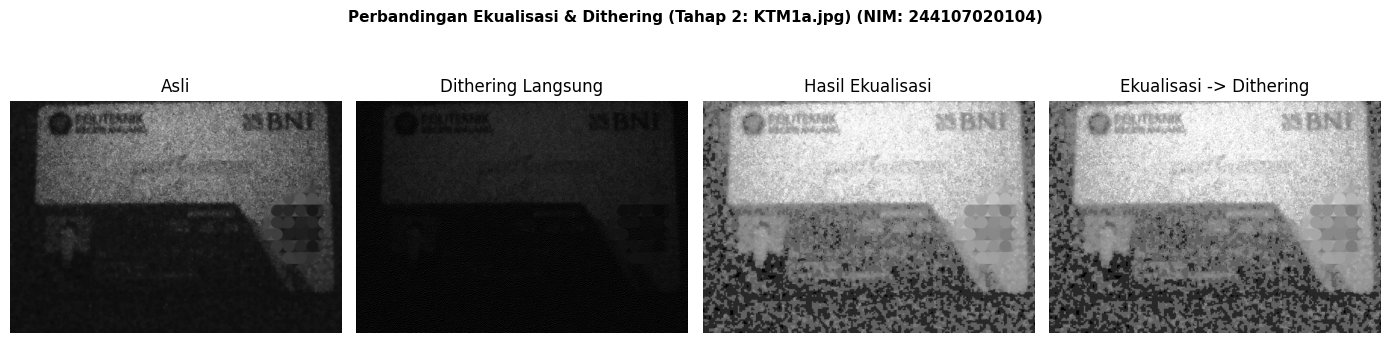

In [93]:
# ==========================================
# E-3 TUGAS PRAKTIKUM DITHERING FLOYD-STEINBERG
# ==========================================
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Mendefinisikan CONTOH dan BASE secara aman merujuk pada BASE_PATH
CONTOH = BASE_PATH
BASE = BASE_PATH

# Menghitung ulang parameter L secara lokal jika PARAM terhapus/berubah
N_local = int(NIM[-3:])
L_param = 2 ** ((N_local % 3) + 1)

# Fungsi algoritma Error Diffusion Floyd-Steinberg sesuai flowchart modul
def floyd_steinberg(gray, L=2):
    # Simpan citra kerja sebagai float
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1) if L > 1 else 255.0
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            # Kuantisasi ke level terdekat
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru # Hitung selisih error

            # Distribusi error ke piksel tetangga sesuai kernel Floyd-Steinberg
            if x + 1 < W:
                img[y, x + 1] += error * 7 / 16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:
                img[y + 1, x] += error * 5 / 16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1 / 16

    # Batasi nilai ke 0-255 lalu ubah ke uint8
    return np.clip(img, 0, 255).astype(np.uint8)

# ==========================================
# 1. TAHAP 1 & 2: Dithering Standar (Floyd-Steinberg)
# ==========================================
# Tahap 1 menggunakan lena.png (bukan lena.jpg karena di Drive berformat .png)
pengujian_dithering = [
    ("Tahap 1: lena.png", CONTOH + 'lena.png'),
    ("Tahap 2: KTM1b.jpg", BASE + 'KTM1b.jpg')
]

for label, path_file in pengujian_dithering:
    print(f"Menjalankan Dithering untuk {label} (L = {L_param})...")
    img_bgr = cv.imread(path_file)
    if img_bgr is None:
        print(f"Gagal membaca file dari {path_file}. Lewati.")
        continue

    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # Jalankan algoritma Floyd-Steinberg dengan level L dari parameter NIM
    img_dithered = floyd_steinberg(img_gray, L=L_param)

    # Tampilkan perbandingan sebelum dan sesudah dithering
    plt.figure(figsize=(10, 5))
    plt.suptitle(f"Dithering Floyd-Steinberg ({label}, L={L_param}) (NIM: {NIM})", fontsize=11, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Citra Grayscale Asli")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_dithered, cmap='gray')
    plt.title(f"Hasil Dithering (L = {L_param})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 2. EKUALISASI LALU DITHERING vs DITHERING LANGSUNG
# ==========================================
# Tahap 1 menggunakan lena.png karena lena_lc.jpg kemungkinan tidak ada di Drive Anda
pengujian_ekualisasi = [
    ("Tahap 1: lena.png", CONTOH + 'lena.png'),
    ("Tahap 2: KTM1a.jpg", BASE + 'KTM1a.jpg')
]

for label, path_file in pengujian_ekualisasi:
    print(f"Menjalankan Analisis Ekualisasi & Dithering untuk {label}...")
    img_bgr = cv.imread(path_file)
    if img_bgr is None:
        print(f"Gagal membaca file dari {path_file}. Lewati.")
        continue

    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    # a. Dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg(img_gray, L=2)

    # b. Ekualisasi histogram terlebih dahulu, kemudian dithering
    img_eq = cv.equalizeHist(img_gray)
    dither_setelah_eq = floyd_steinberg(img_eq, L=2)

    # Tampilkan 4 layout perbandingan sesuai modul
    plt.figure(figsize=(14, 4))
    plt.suptitle(f"Perbandingan Ekualisasi & Dithering ({label}) (NIM: {NIM})", fontsize=11, fontweight='bold')

    plt.subplot(1, 4, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Asli")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(dither_langsung, cmap='gray')
    plt.title("Dithering Langsung")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(img_eq, cmap='gray')
    plt.title("Hasil Ekualisasi")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(dither_setelah_eq, cmap='gray')
    plt.title("Ekualisasi -> Dithering")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Jawaban Analisis Pertanyaan Praktikum E-3
1. Perbedaan Dithering Langsung vs Ekualisasi lalu Dithering:

- Ketika citra beruntun gelap langsung dikenakan dithering (L=2), informasi pada area gelap akan hilang dan menyatu menjadi blok hitam pekat karena sebaran intensitas awalnya menumpuk di sisi kiri histogram.
- Sebaliknya, jika citra diekualisasi terlebih dahulu agar kontras dan penyebaran intensitasnya merata, lalu diterapkan dithering Floyd-Steinberg, detail piksel dan transisi tepi objek akan terjaga dengan sangat baik.

2. Urutan Mana yang Menghasilkan Teks pada KTM Lebih Terbaca?
- Urutan Ekualisasi terlebih dahulu, kemudian Dithering (ekualisasi lalu dithering) menghasilkan teks yang jauh lebih tajam dan mudah dibaca. Ekualisasi memperbaiki rentang dinamis citra yang redup, sementara dithering mempertahankan ilusi gradasi dan memperkuat ketegasan tepi karakter teks meskipun kedalaman level warna diturunkan menjadi biner (L=2).